<a href="https://colab.research.google.com/github/PraveenChigurla/GrowTech-Tasks/blob/main/Multiple_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

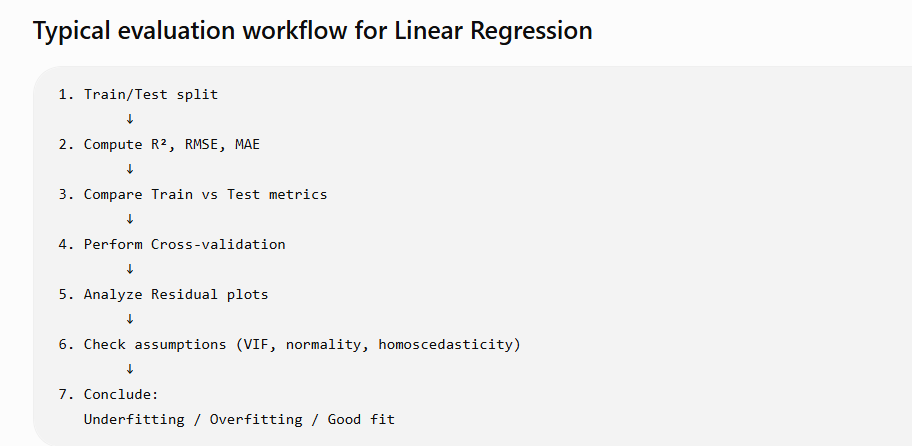

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [64]:
warnings.simplefilter(action='ignore',category=FutureWarning)

In [65]:
df = pd.read_csv('/content/Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


# **Observe dataset**

In [66]:
df.shape

(10000, 6)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [68]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [69]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


# **Handling Null values**

In [70]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


# **Handling duplicate values**

In [71]:
df.duplicated().sum()

np.int64(127)

In [72]:
df.drop_duplicates(inplace=True)

In [73]:
df.duplicated().sum()

np.int64(0)

# **Visualisation**

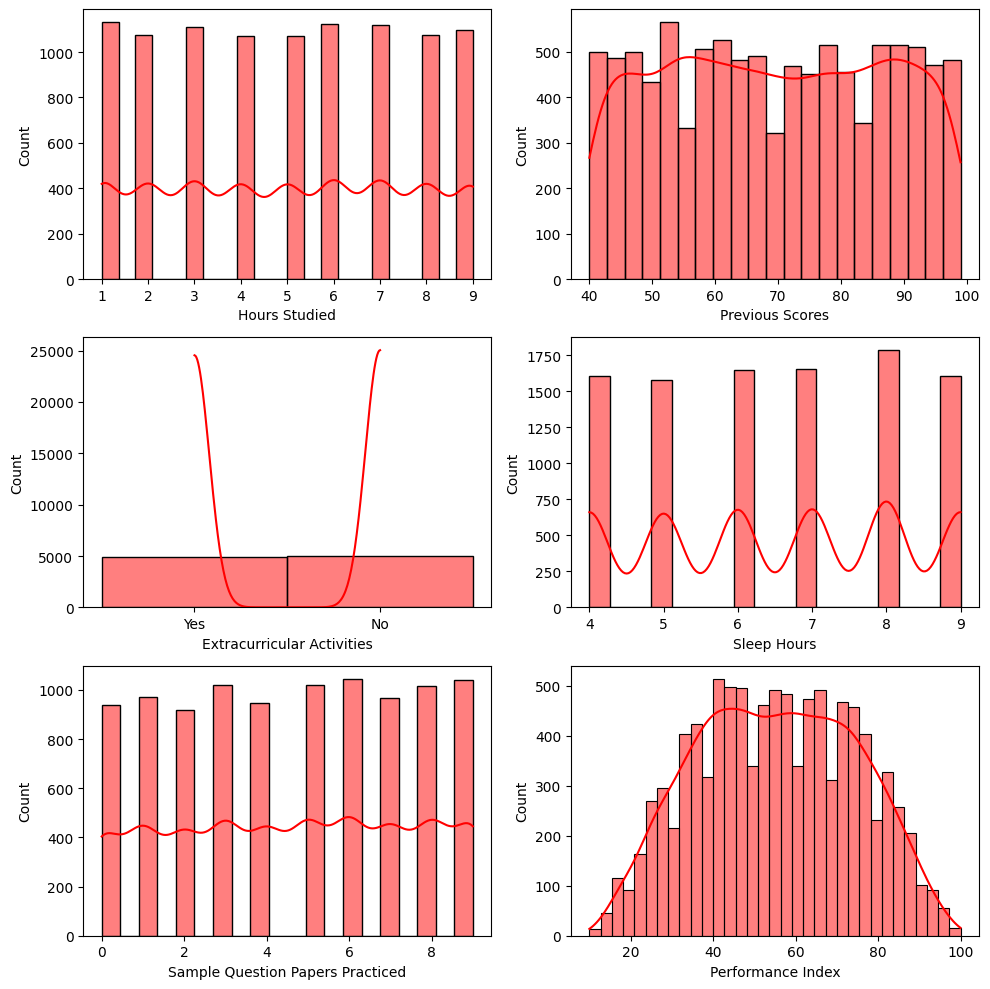

In [74]:
plt.figure(figsize=(10,10))
j=0
for i in df.columns:
  j+=1
  plt.subplot(3,2,j)
  sns.histplot(data=df,x=i,color='r',kde=True)
  plt.tight_layout()

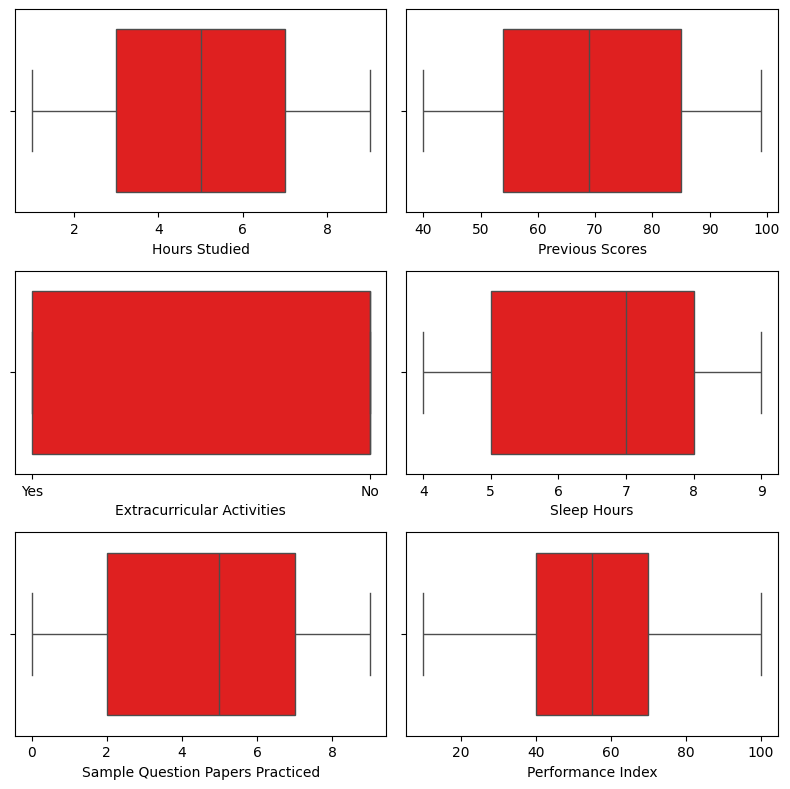

In [75]:
plt.figure(figsize=(8,8))
j=0
for i in df.columns:
  j+=1
  plt.subplot(3,2,j)
  sns.boxplot(data=df,x=i,color='r')
  plt.tight_layout()

<Axes: xlabel='Extracurricular Activities', ylabel='Performance Index'>

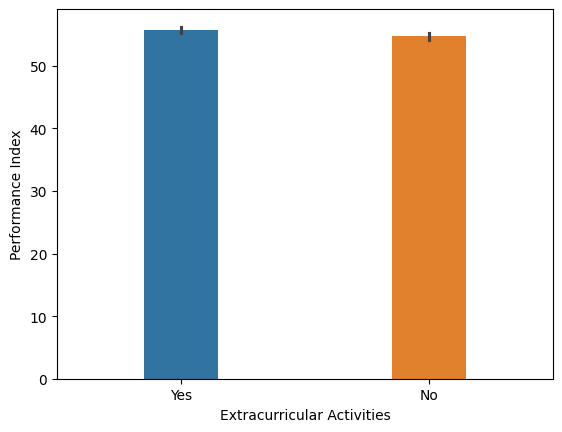

In [76]:
sns.barplot(data=df, x=df['Extracurricular Activities'],y='Performance Index', width=0.3, hue=df['Extracurricular Activities'])

Assumptions of Regression: **LINE(Linearity[** Independent vs Target should be Linear**], **Independent** [The observations should not be dependent on other observations], **Normality**[The errors curve should be like bell structured..normal distribution],**Equal variance**(Homoscedasticity)[The errors should be consistent not spread about the best fit line**], **Multi collinearity**[The variables should be independent of each other not depending on other variables]

In [77]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

# **LINEARITY**

In [78]:
Y=df['Performance Index']
X=df.drop('Performance Index',axis=1)

  Hours Studied: Slope ==>> 2.7846
  Previous Scores: Slope ==>> 1.0146
  Sleep Hours: Slope ==>> 0.5697
  Sample Question Papers Practiced: Slope ==>> 0.2910


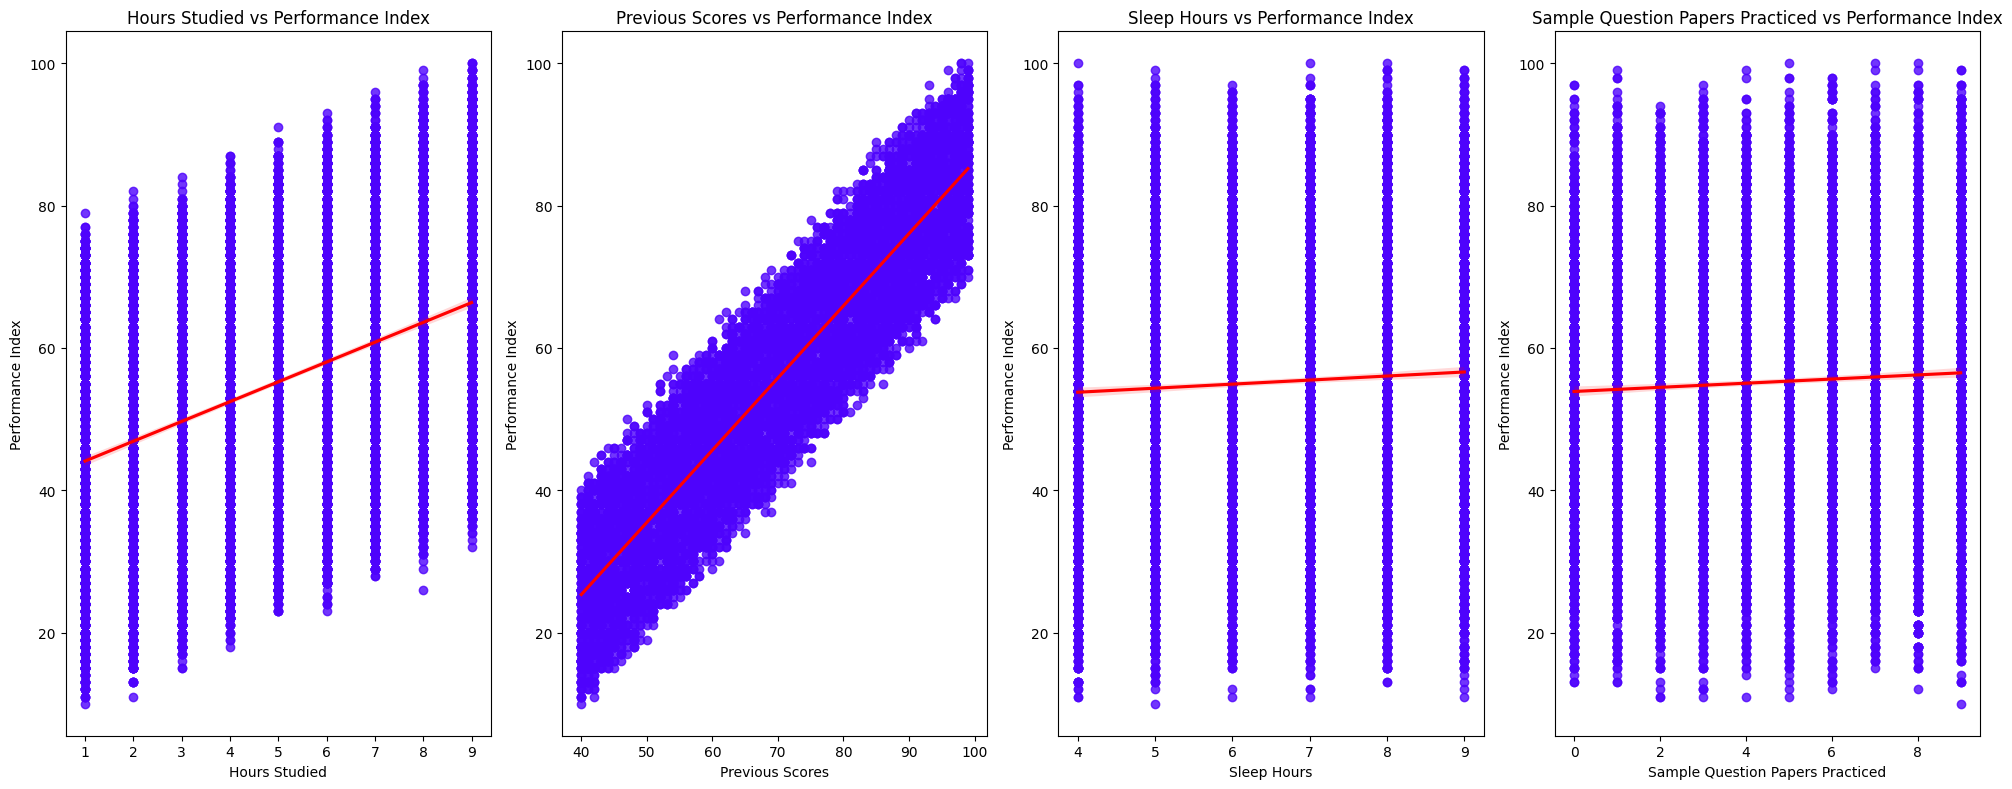

In [79]:
from scipy.stats import linregress

plt.figure(figsize=(20,8))
j=0
for i in X.select_dtypes(include='number'):
    j+=1
    plt.subplot(1,4,j)
    plt.title(f"{i} vs {Y.name}")
    sns.regplot(data=df, x=i,y=Y,color='#4e03fc', line_kws={'color':'r'})
    plt.tight_layout()

    slope, intercept, r_value, p_value, std_err = linregress(X[i], Y)
    print(f"  {i}: Slope ==>> {slope:.4f}")

# **Multi Collinearity**

  Hours Studied - Hours Studied: Slope ==>>       1.0000

  Hours Studied - Previous Scores: Slope ==>>       -0.0714

  Hours Studied - Sleep Hours: Slope ==>>       0.0014

  Hours Studied - Sample Question Papers Practiced: Slope ==>>       0.0174

  Hours Studied - Performance Index: Slope ==>>       2.7846

  Previous Scores - Hours Studied: Slope ==>>       -0.0016

  Previous Scores - Previous Scores: Slope ==>>       1.0000

  Previous Scores - Sleep Hours: Slope ==>>       0.0008

  Previous Scores - Sample Question Papers Practiced: Slope ==>>       0.0014

  Previous Scores - Performance Index: Slope ==>>       1.0146

  Sleep Hours - Hours Studied: Slope ==>>       0.0032

  Sleep Hours - Previous Scores: Slope ==>>       0.0814

  Sleep Hours - Sleep Hours: Slope ==>>       1.0000

  Sleep Hours - Sample Question Papers Practiced: Slope ==>>       0.0083

  Sleep Hours - Performance Index: Slope ==>>       0.5697

  Sample Question Papers Practiced - Hours Studied: Slope =

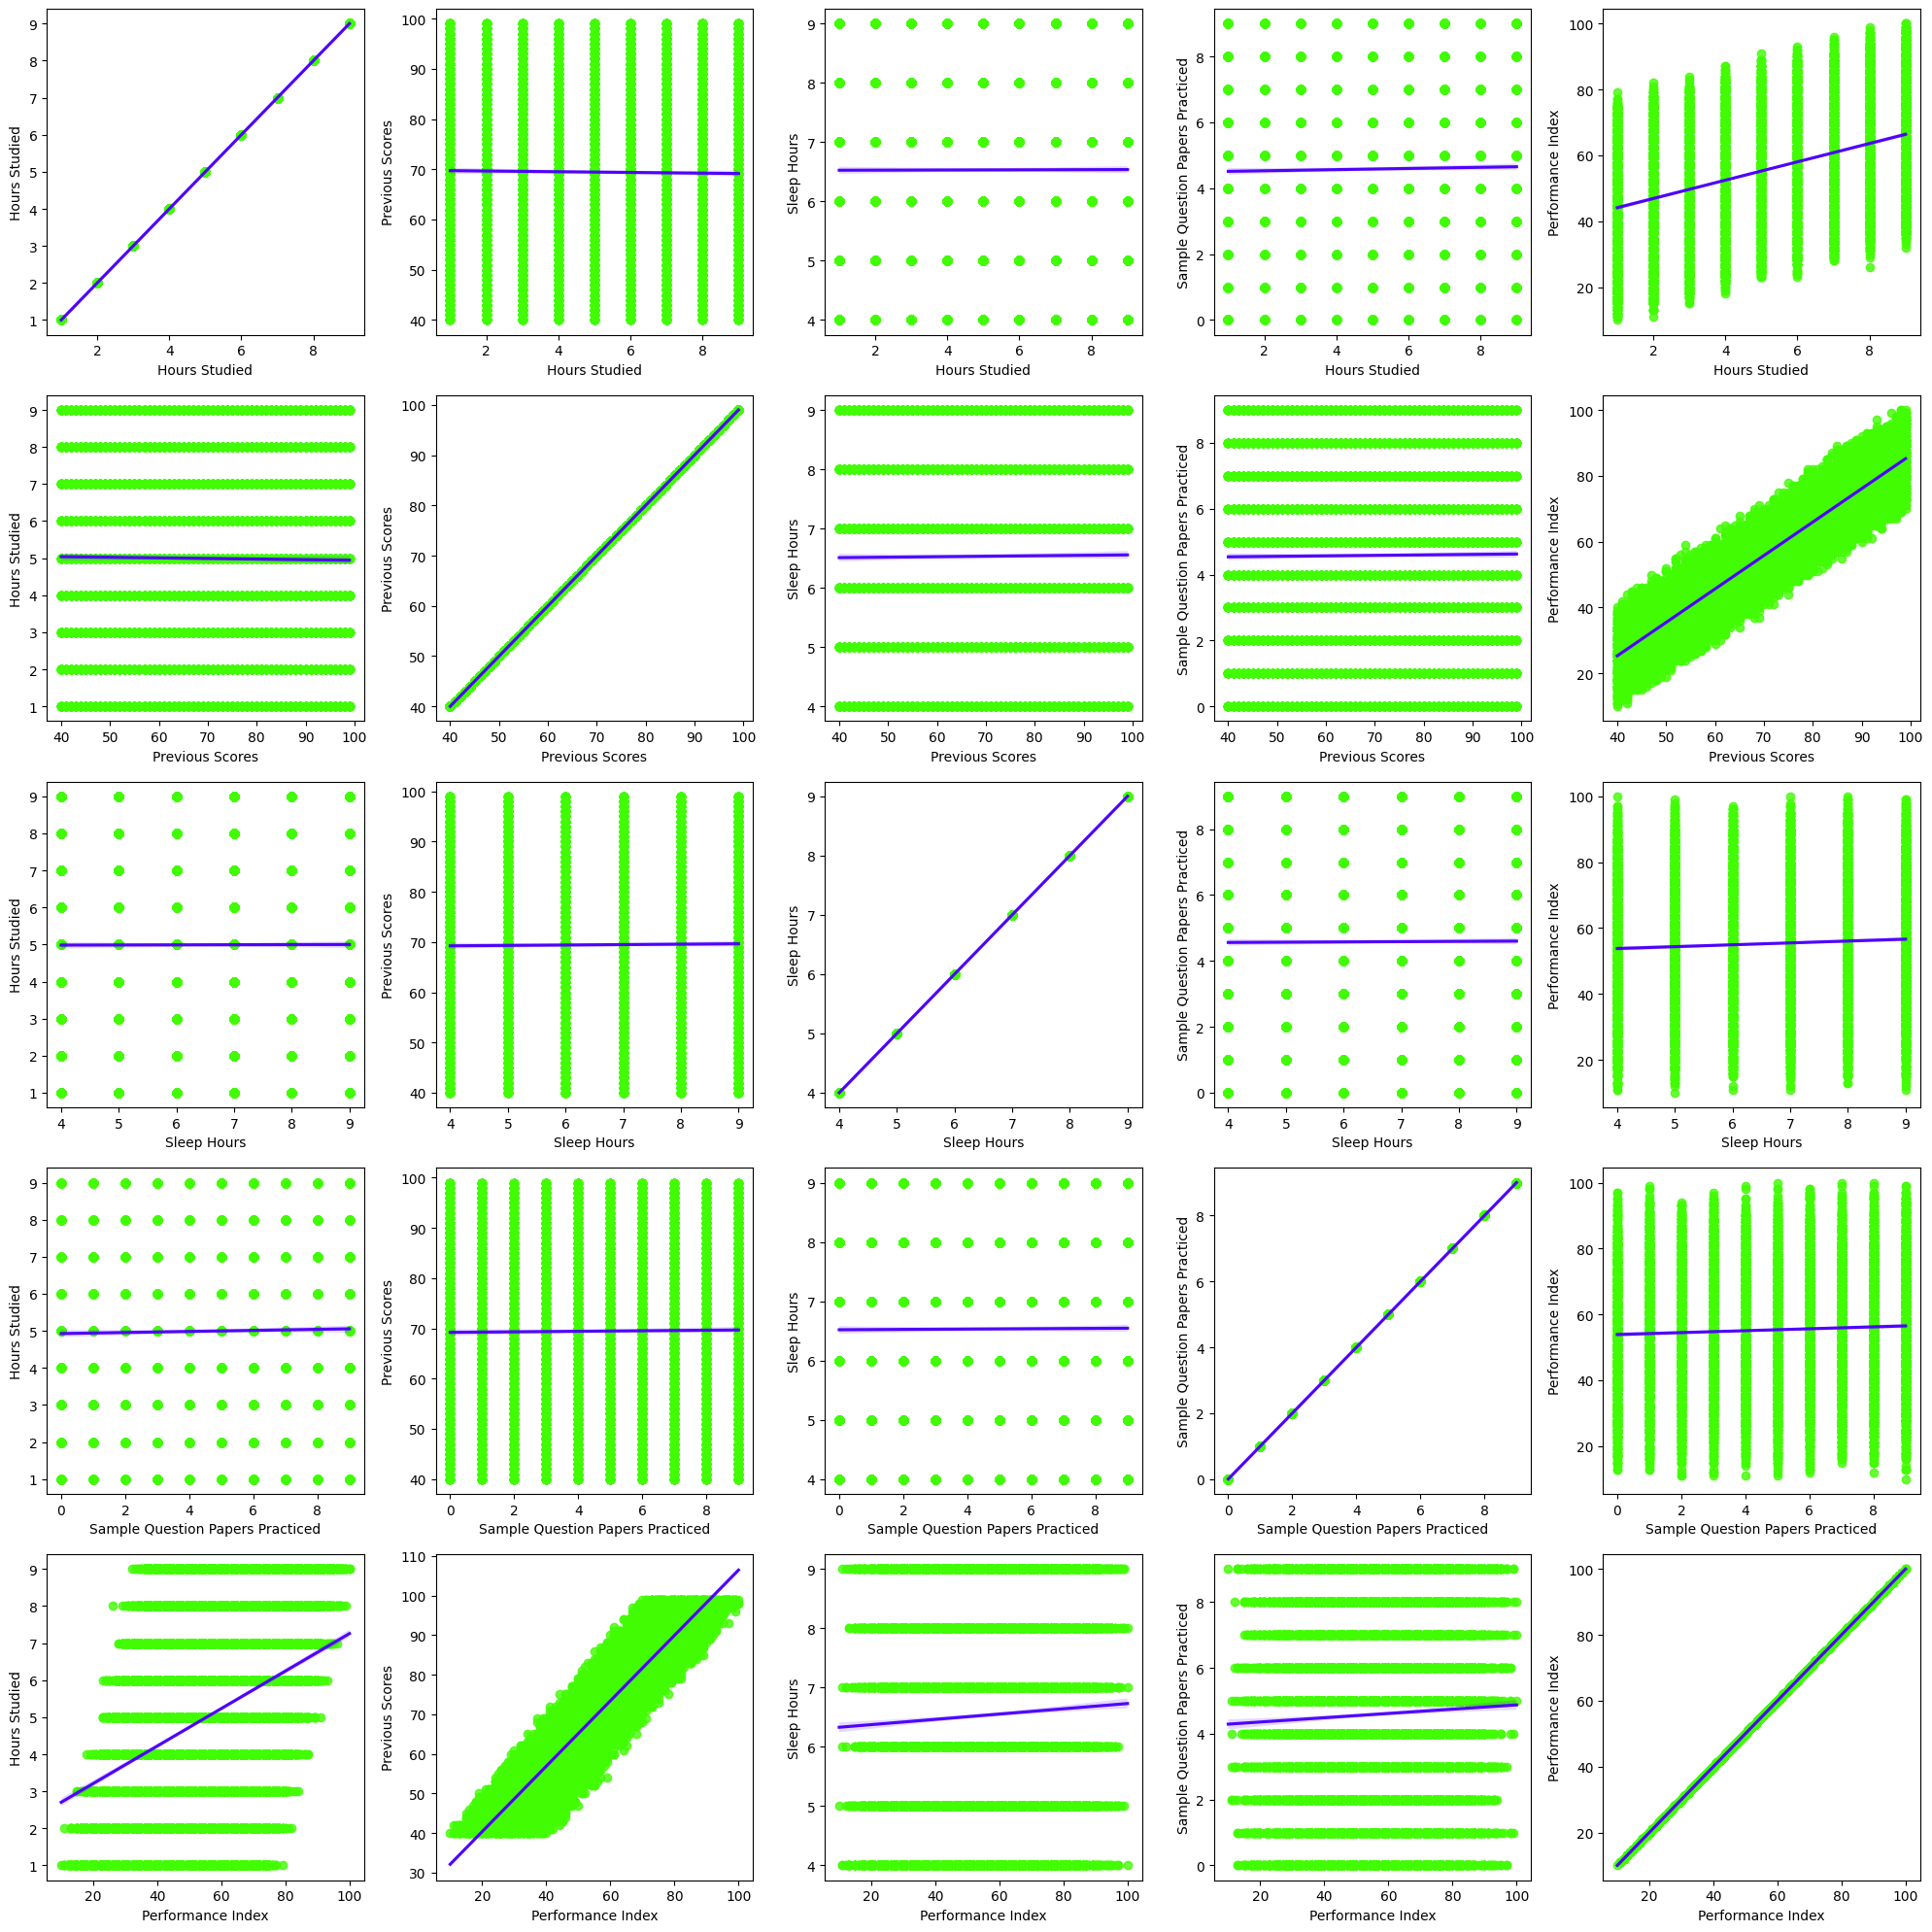

In [80]:
from scipy.stats import linregress
plt.figure(figsize=(20,20))
j=0
for i in df.select_dtypes(include='number'):
  for k in df.select_dtypes(include='number'):
    j+=1
    # if i!=k:
    plt.subplot(5,5,j)
    sns.regplot(data=df,x=i,y=k,color='#41fc03', line_kws={'color':'#4e03fc'})
    plt.tight_layout()

    slope, intercept, r_value, p_value, std_err = linregress(df[i],df[k])
    print(f"  {i} - {k}: Slope ==>>       {slope:.4f}")
    print()

# **Multi Collinearity**(Correlation)

<Axes: >

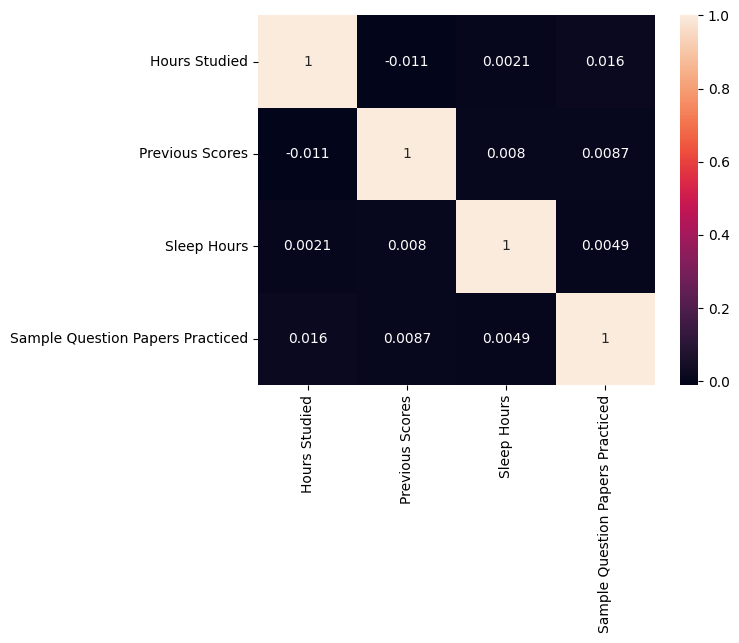

In [81]:
# sns.heatmap(df.select_dtypes(include='number').corr(numeric_only=True), annot=True)
sns.heatmap((df.select_dtypes(include='number')).drop('Performance Index',axis=1).corr(), annot=True)

# **Model Training**

In [82]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [83]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
df['Extracurricular Activities']=le.fit_transform(df['Extracurricular Activities'])
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [84]:
Y=df['Performance Index']
X=df.drop('Performance Index',axis=1)

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, Y_train, Y_test= train_test_split(X,Y, test_size=0.2, random_state=42)

model=LinearRegression()
model.fit(X_train,Y_train)


LinearRegression()

# **Model Testing**

In [86]:
Y_pred=model.predict(X_test)
Y_pred

array([46.48001281, 80.2853795 , 61.06518835, ..., 77.08443628,
       86.24676576, 35.8793377 ])

In [87]:
residual=Y_test - Y_pred
residual

,Performance Index
6099,0.519987
106,-4.285379
9265,0.934812
4707,0.293685
2155,1.163132
...,...
8732,0.722165
3112,-1.310084
5297,-0.084436
6116,1.753234


# **Normality**

<Axes: xlabel='Performance Index', ylabel='Count'>

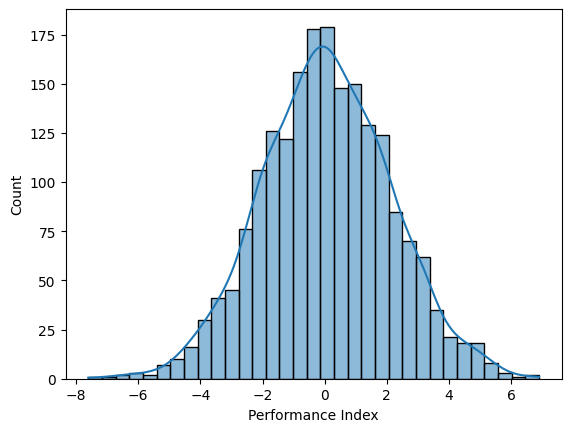

In [88]:
# sns.displot(x=residual, kind='kde')
sns.histplot(x=residual, kde=True)

# **Homoscedasticity**

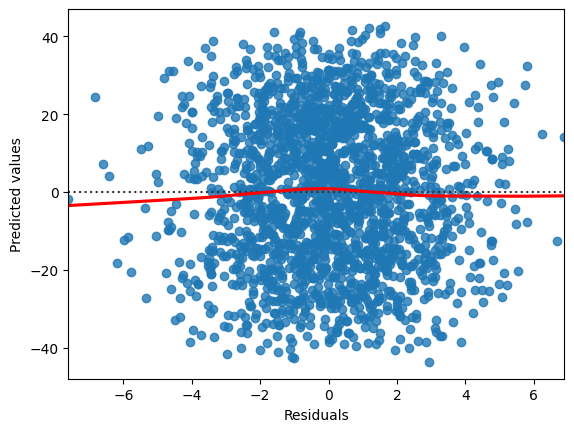

In [89]:
sns.residplot(y=Y_pred, x=residual, lowess=True, line_kws={'color':'r'})
plt.xlabel("Residuals")
plt.ylabel("Predicted values")
plt.show()

# **Independence of Observations**

In [90]:
from statsmodels.stats.stattools import durbin_watson

# The Durbin-Watson test statistic will be calculated on the residuals (residual)
dw_statistic = durbin_watson(residual)

print(f"Durbin-Watson statistic: {dw_statistic:.4f}")

if dw_statistic < 1.5 or dw_statistic > 2.5:
    print("There might be an issue with autocorrelation (lack of independence) in the residuals.")
else:
    print("The Durbin-Watson statistic suggests no significant autocorrelation in the residuals (observations are likely independent).")

Durbin-Watson statistic: 2.0398
The Durbin-Watson statistic suggests no significant autocorrelation in the residuals (observations are likely independent).


### Visual Inspection: Residuals vs. Order of Observation

Another way to residual for independence, especially if your data has a logical sequence or order (e.g., time-series data), is to plot the residuals against their observation order or index. If the residuals are independent, you should see a random scatter of points with no discernible pattern.

In [91]:
residual

,Performance Index
6099,0.519987
106,-4.285379
9265,0.934812
4707,0.293685
2155,1.163132
...,...
8732,0.722165
3112,-1.310084
5297,-0.084436
6116,1.753234


In [92]:
residual.index

Index([6099,  106, 9265, 4707, 2155, 6594, 9438, 8905, 2012,  568,
       ...
       8347, 7150, 2309, 1056,  233, 8732, 3112, 5297, 6116, 5088],
      dtype='int64', length=1975)

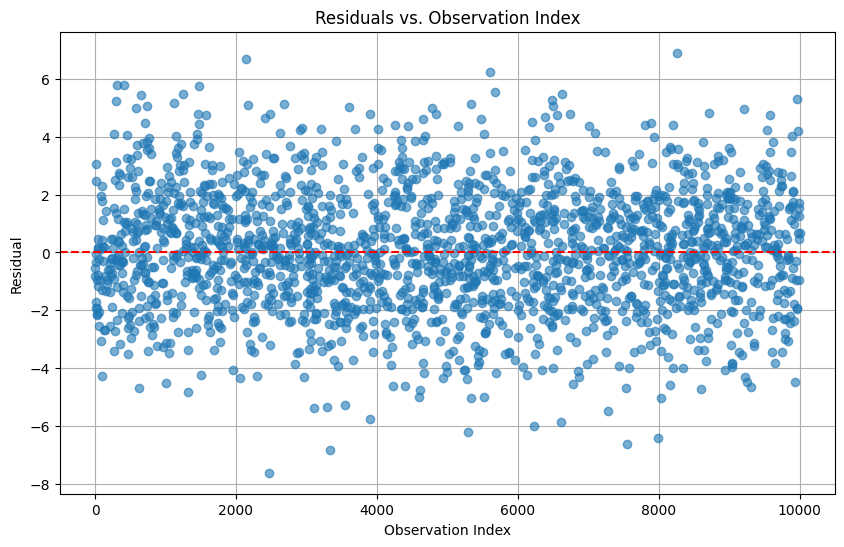

In [93]:
plt.figure(figsize=(10, 6))
plt.plot(residual.index, residual, 'o', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Observation Index')
plt.xlabel('Observation Index')
plt.ylabel('Residual')
plt.grid(True)
plt.show()


# **Model's Performance Analysis**

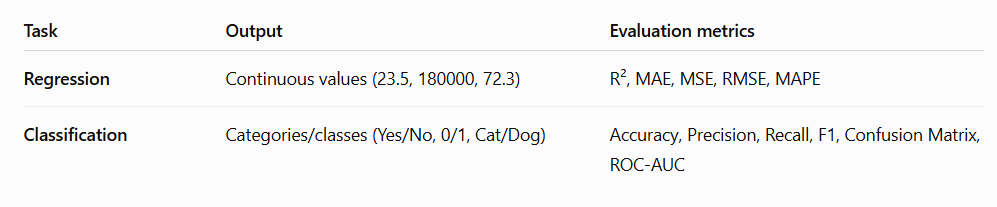

**R²:** A percentage score showing how much better your model is at predicting the data. [In simple terms it tells how well the model learnt the patterns in the data.]

In [94]:
from sklearn.metrics import r2_score

r2 = r2_score(Y_test, Y_pred)
r2

0.9884301209927054

**MAE (Mean Absolute Error)**: Average absolute prediction error.

In [95]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(Y_test, Y_pred)
mae

1.6469703984255573

In [96]:
# model.score()

**MSE (Mean Squared Error)**: Average squared error.(Penalizes large errors more heavily.)

In [97]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(Y_test, Y_pred)
mse


4.305900938538479

**RMSE (Root Mean Squared Error)**: Square root of MSE.

In [98]:
rmse = mean_squared_error(Y_test, Y_pred) ** 0.5
rmse

2.0750664901488047

In [99]:
#from sklearn.model_selection import train_test_split
#from sklearn.linear_model import LinearRegression
# from sklearn.metrics import (
#     r2_score,
#     mean_absolute_error,
#     mean_squared_error
# )

# X_train, X_test, y_train, y_test=train_test_split( X, Y,test_size=0.2, random_state=40)
# model = LinearRegression()

# model.fit(X_train, y_train)

# y_pred = model.predict(X_test)

# print("R2 :", r2_score(y_test, y_pred))

# print("MAE:", mean_absolute_error(y_test, y_pred))

# print("MSE:", mean_squared_error(y_test, y_pred))

# print("RMSE:", mean_squared_error(y_test, y_pred)**0.5)

# **Overfitting/Underfitting/Best Fit check**

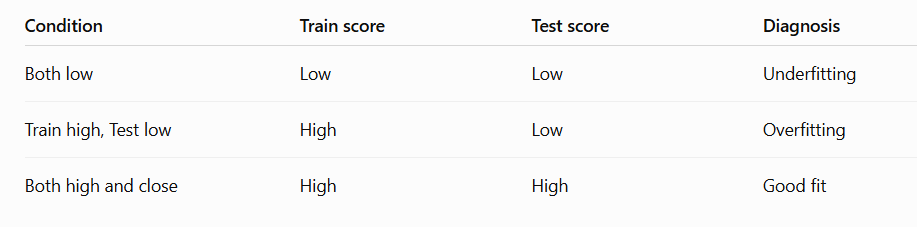

In [100]:
from sklearn.metrics import r2_score, mean_squared_error

# Train predictions
y_train_pred = model.predict(X_train)

# Test predictions
y_test_pred = model.predict(X_test)

print("Train R²:", r2_score(Y_train, y_train_pred))
print("Test R² :", r2_score(Y_test, y_test_pred))

print("Train RMSE:", mean_squared_error(Y_train, y_train_pred)**0.5)
print("Test RMSE :", mean_squared_error(Y_test, y_test_pred)**0.5)

Train R²: 0.9887391160677558
Test R² : 0.9884301209927054
Train RMSE: 2.0358228155328564
Test RMSE : 2.0750664901488047


**Observation:** Best fitting

# **Cross-validation**: Instead of relying on one.

In [101]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    Y,
    cv=5,
    scoring='r2'
)

print(scores.mean())

0.9886613898881287


# **Testing with unseen data**

In [102]:
new_df=df.head(2).drop('Performance Index', axis=1)
new_df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2


In [103]:
new_df.iloc[0]=[4,95,1,12,0]
new_df.iloc[1]=[12,85,0,6,3]
new_df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,4,95,1,12,0
1,12,85,0,6,3


In [104]:
Pred=model.predict(new_df)

In [105]:
Pred

array([80.41234821, 90.19606821])

In [106]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [107]:
unseen=df.sample(5)
unseen

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
5487,2,49,0,8,4,28.0
3443,7,96,0,9,1,89.0
8935,8,44,1,5,6,39.0
7516,6,86,0,6,5,74.0
543,5,84,0,8,0,70.0


In [108]:
model.predict(unseen.drop('Performance Index',axis=1))

array([26.15520711, 88.18250506, 37.70419719, 74.48577448, 69.59852019])